# Proyecto Dataset Diabético

## 📊 Resumen del Dataset

- **Dimensiones**: 101,766 registros × 50 columnas
- **Variable objetivo**: `readmitted` (NO, <30 días, >30 días)
- **Tipo de problema**: Clasificación multiclase (puede convertirse a binaria)

---


In [141]:
pip install pandas numpy scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [142]:
pip install pandas numpy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [143]:
pip install jinja2

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [144]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    classification_report, 
    recall_score, 
    precision_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_classification
from sklearn.utils import shuffle


warnings.filterwarnings("ignore")

## Limpieza y Preprocesamiento de Datos

In [146]:
df = pd.read_csv("diabetic_data.csv")
    
print(f"\n✓ Dataset cargado exitosamente")
print(f"  Dimensiones originales: {df.shape[0]} filas × {df.shape[1]} columnas")


✓ Dataset cargado exitosamente
  Dimensiones originales: 101766 filas × 50 columnas


In [147]:
# Eliminar columnas con >50% nulos
cols_to_drop = ['weight', 'max_glu_serum', 'medical_specialty', 'payer_code']

# Reemplazar '?' por NaN
df = df.replace('?', np.nan)

# Eliminar IDs (no aportan información predictiva)
df = df.drop(['encounter_id', 'patient_nbr'], axis=1)

### Imputación de Nulos Menores

In [148]:
# Race, diag_2, diag_3
df['race'] = df['race'].fillna('Unknown')
df['diag_2'] = df['diag_2'].fillna('Missing')
df['diag_3'] = df['diag_3'].fillna('Missing')

### Transformación de Variable Objetivo

In [149]:
# Opción 1: Readmitido vs No readmitido ¿?
df['readmitted_binary'] = (df['readmitted'] != 'NO').astype(int)

# Opción 2: Readmitido en <30 días vs resto  ¿?
df['early_readmission'] = (df['readmitted'] == '<30').astype(int)

In [150]:

def cargar_y_preparar(filename='diabetic_data.csv'):
    """
    Càrrega i preparació inicial (conversió de '?' a NaN i Label Encoding).
    Gestió del FileNotFoundError.
    """
    try:
        df = pd.read_csv(filename)
    except FileNotFoundError:
        # Missatge clar i retorn de None per indicar fallada
        print(f" ERROR: No s'ha trobat el fitxer '{filename}'. Revisa que la ruta sigui correcta.")
        return None, None
    except Exception as e:
        # Captura qualsevol altre error de càrrega (ex: format, codificació)
        print(f" ERROR inesperat durant la càrrega del fitxer: {e}")
        return None, None
    
    # Resta del teu codi de neteja
    df = df.replace('?', np.nan)
    df = df.drop(['weight', 'payer_code', 'medical_specialty', 'encounter_id', 'patient_nbr'], axis=1, errors='ignore')
    if len(df) > 5000:
        df = df.sample(n=5000, random_state=42).reset_index(drop=True) 

    df['readmitted'] = df['readmitted'].replace({'NO': 0, '<30': 1, '>30': 1})
    y = df['readmitted']
    X_raw = df.drop('readmitted', axis=1)

    for col in X_raw.columns:
        if X_raw[col].dtype == 'object':
            le = LabelEncoder()
            mask_nan = X_raw[col].isna()
            series_temp = X_raw[col].astype(str).copy()
            series_temp[mask_nan] = 'MISSING_VALUE'
            X_raw[col] = le.fit_transform(series_temp)
            X_raw.loc[mask_nan, col] = np.nan
            X_raw[col] = X_raw[col].astype(float)
    
    return X_raw, y

In [151]:
resultados={}

print("--- INICIANT ANÀLISI COMPARATIVA DE TÈCNIQUES D'IMPUTACIÓ ---")
X_base, y_base = cargar_y_preparar()

nulos_antes_total = X_base.isnull().sum().sum()
nulos_antes_detalle = X_base.isnull().sum()[X_base.isnull().sum() > 0].sort_values(ascending=False)
print("\n--- Nulos Iniciales ---")
print(nulos_antes_detalle)
print(f"Total de nuls a imputar: {nulos_antes_total}")

--- INICIANT ANÀLISI COMPARATIVA DE TÈCNIQUES D'IMPUTACIÓ ---

--- Nulos Iniciales ---
max_glu_serum    4740
A1Cresult        4154
race              113
diag_3             73
diag_2             16
diag_1              1
dtype: int64
Total de nuls a imputar: 9097


✅ Dades Base Sincronitzades. Mida inicial: 5000 mostres.

🟡 ESTRATÈGIA: IMPUTACIÓ PER MITJANA (Mean)
✅ Imputació per Mitjana completada per a tots els models.
✅ Split i Escalat completats.

▶️ Avaluació del Model: SVM
  Accuracy: 0.6240
  Matriu de Confusió:
[[393 142]
 [234 231]]

  📑 INFORME DETALLAT:
                precision    recall  f1-score   support

No Readmès (0)       0.63      0.73      0.68       535
   Readmès (1)       0.62      0.50      0.55       465

      accuracy                           0.62      1000
     macro avg       0.62      0.62      0.61      1000
  weighted avg       0.62      0.62      0.62      1000


▶️ Avaluació del Model: KNN
  Accuracy: 0.6150
  Matriu de Confusió:
[[365 170]
 [215 250]]

  📑 INFORME DETALLAT:
                precision    recall  f1-score   support

No Readmès (0)       0.63      0.68      0.65       535
   Readmès (1)       0.60      0.54      0.56       465

      accuracy                           0.61      1000
     macro avg

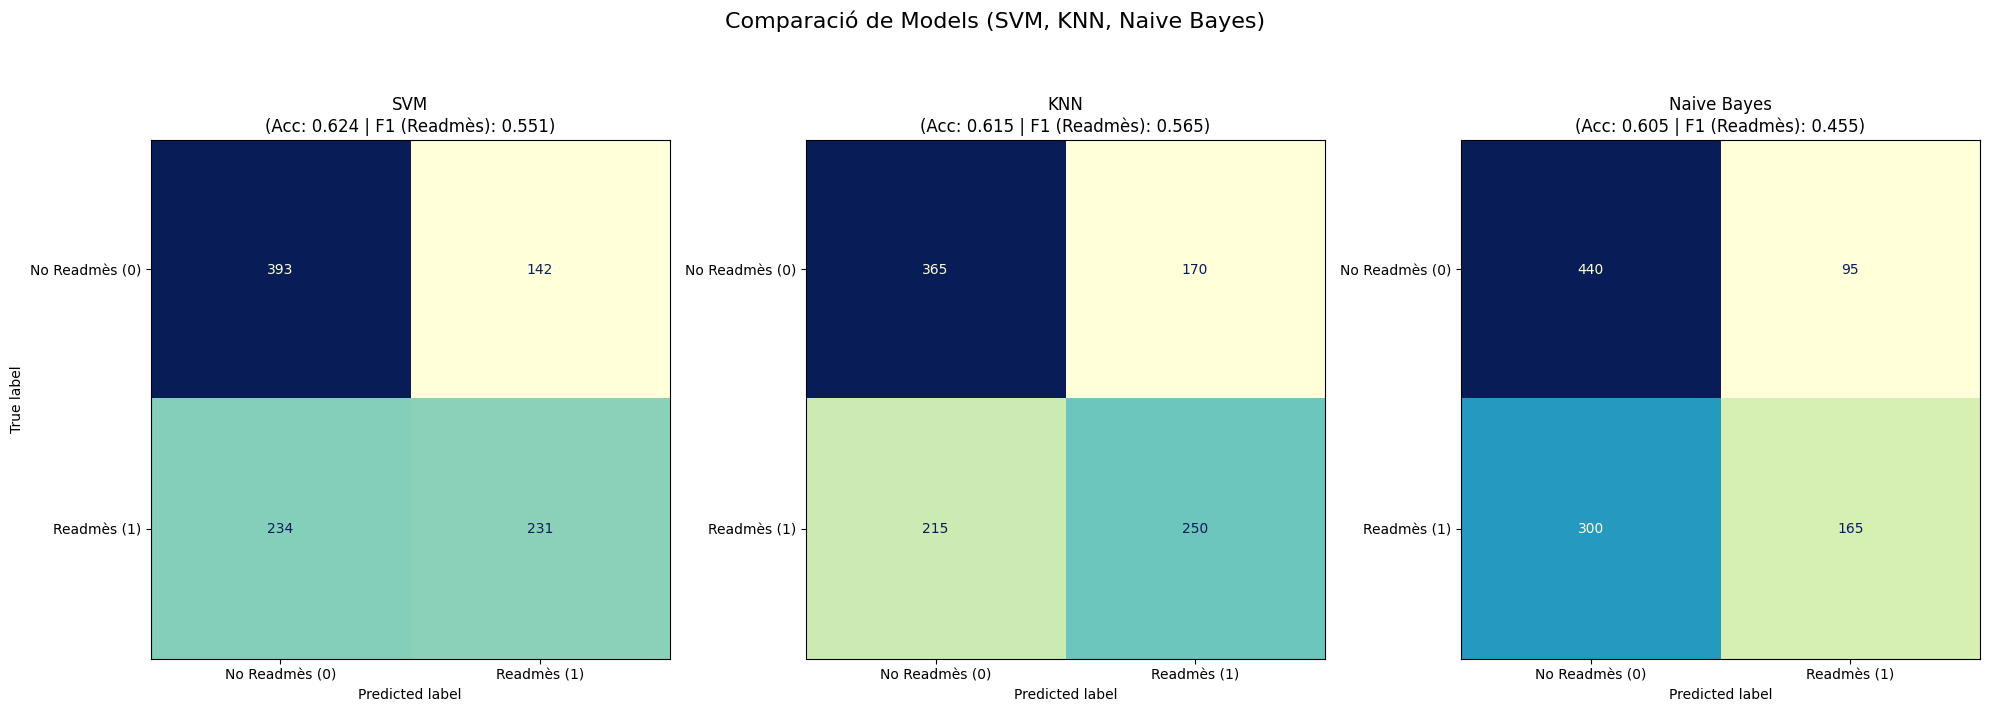

In [167]:
X_base, y_base = cargar_y_preparar(filename='diabetic_data.csv')

if X_base is None:
    # Si la carga falló, detener la ejecución.
    print("\n⚠️ Procés aturat a causa d'un error de càrrega o preparació inicial.")
else:
    print(f"✅ Dades Base Sincronitzades. Mida inicial: {X_base.shape[0]} mostres.")

    # --- PASO 1: IMPUTACIÓN POR MITJANA (Mean) ---
    print("\n🟡 ESTRATÈGIA: IMPUTACIÓ PER MITJANA (Mean)")
    imputer_mean = SimpleImputer(strategy='mean')
    # Aplicar la imputación a los datos preparados (que ahora tienen NaN de las categorías y valores numéricos)
    X_mean_imputed_array = imputer_mean.fit_transform(X_base)
    X_mean_imputed = pd.DataFrame(X_mean_imputed_array, columns=X_base.columns)
    print("✅ Imputació per Mitjana completada per a tots els models.")

    # --- PASO 2: PREPARACIÓN DE DADES (SPLIT Y ESCALAT) ---
    X_train, X_test, y_train, y_test = train_test_split(
        X_mean_imputed, y_base, test_size=0.2, random_state=42, stratify=y_base
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    print("✅ Split i Escalat completats.")

    # --- PASO 3: DEFINICIÓN DE LOS MODELOS (SVM, KNN, Naive Bayes) ---
    models_to_test = {
        'SVM': SVC(random_state=42),
        'KNN': KNeighborsClassifier(n_neighbors=5),
        'Naive Bayes': GaussianNB()
    }

    results = []
    display_labels = ['No Readmès (0)', 'Readmès (1)']

    # --- PASO 4: ENTRENAMIENTO Y EVALUACIÓN DETALLADA DE CADA MODELO ---
    for name, model in models_to_test.items():
        print(f"\n▶️ Avaluació del Model: {name}")
        
        # Entrenament
        model.fit(X_train_scaled, y_train)
        
        # Predicción
        y_pred = model.predict(X_test_scaled)
        
        # 1. Matriz de Confusión y Accuracy
        acc = accuracy_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)
        
        print(f"  Accuracy: {acc:.4f}")
        print("  Matriu de Confusió:")
        print(cm)
        
        # 2. Informe de Clasificación Detallado (Precision, Recall, F1)
        report = classification_report(y_test, y_pred, target_names=display_labels, output_dict=True, zero_division=0)
        print("\n  📑 INFORME DETALLAT:")
        print(classification_report(y_test, y_pred, target_names=display_labels, zero_division=0))

        # Guardar resultados para la visualización (Incluye F1 de la clase positiva)
        # La clase positiva ('Readmès (1)') es el foco en problemas de salud desbalanceados
        f1_readmes = report['Readmès (1)']['f1-score']
        results.append({'name': name, 'cm': cm, 'acc': acc, 'f1': f1_readmes})


    # --- PASO 5: VISUALIZACIÓN DE LAS TRES MATRICES DE CONFUSIÓN ---

    fig, axes = plt.subplots(1, 3, figsize=(20, 7)) 
    plt.suptitle('Comparació de Models (SVM, KNN, Naive Bayes)', fontsize=16)

    for i, res in enumerate(results):
        ax = axes[i]
        cm = res['cm']
        acc = res['acc']
        f1 = res['f1']
        
        # Título que incluye la Accuracy y el F1-Score
        title = f"{res['name']}\n(Acc: {acc:.3f} | F1 (Readmès): {f1:.3f})"
        
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
        # Usar 'd' para formato de números enteros
        disp.plot(ax=ax, cmap='YlGnBu', values_format='d', colorbar=False) 
        disp.ax_.set_title(title)
        
        if i > 0:
            # Eliminar la etiqueta del eje Y en las subgráficas centrales/derechas para limpieza
            disp.ax_.set_ylabel('')
        
    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show() # Esta línea se reemplazará por la generación del gráfico

✅ Dades Base Sincronitzades. Mida final: 5000 mostres.

🔵 ESTRATÈGIA ÚNICA: IMPUTACIÓ PER MODA (Most Frequent)
✅ Imputació per Moda completada per a tots els models.
✅ Split i Escalat completats.

▶️ Avaluació del Model: 1. Regressió Logística
  Accuracy: 0.6050
  Matriu de Confusió:
[[399 136]
 [259 206]]

▶️ Avaluació del Model: 2. K-Nearest Neighbors (KNN)
  Accuracy: 0.5990
  Matriu de Confusió:
[[353 182]
 [219 246]]

▶️ Avaluació del Model: 3. Decision Tree Classifier
  Accuracy: 0.6190
  Matriu de Confusió:
[[445  90]
 [291 174]]


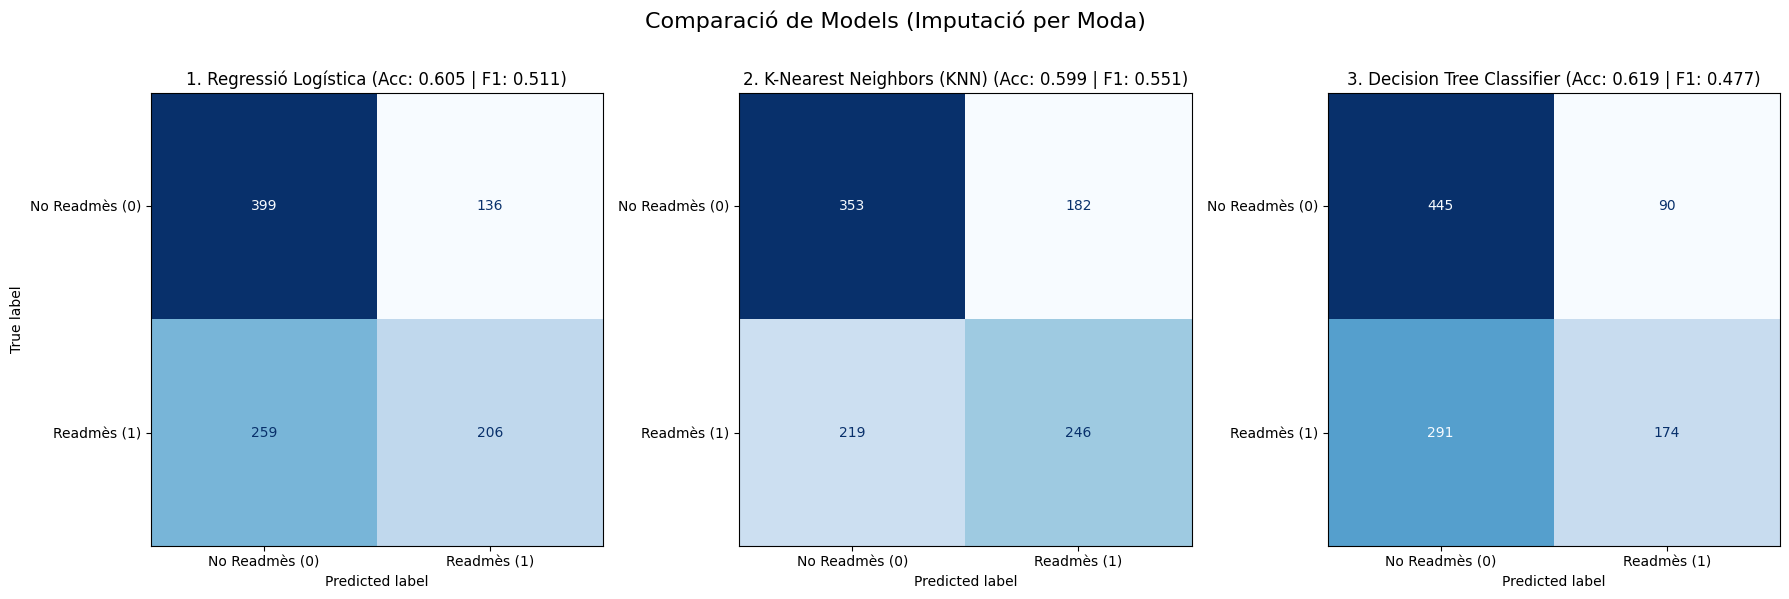

In [168]:
X_base, y_base = cargar_y_preparar(filename='diabetic_data.csv')

if X_base is None:
    print("\n⚠️ Procés aturat a causa d'un error de càrrega o preparació inicial.")
else:
    # Bloque de alineación (asegura que y_base tenga el mismo índice que X_base después de la submuestra)
    try:
        y_base_aligned = y_base.loc[X_base.index]
        y_base = y_base_aligned 
        print(f"✅ Dades Base Sincronitzades. Mida final: {X_base.shape[0]} mostres.")
    except Exception as e:
        print(f"⚠️ ERROR DURANT L'ALINEACIÓ: {e}. Assegura't que X_base i y_base estan definides i són objectes pandas.")

    # --- PASO 1: IMPUTACIÓ PER MODA (Most Frequent) ---
    print("\n" + "="*50)
    print("🔵 ESTRATÈGIA ÚNICA: IMPUTACIÓ PER MODA (Most Frequent)")

    X_input = X_base.copy()
    imputer_mode = SimpleImputer(strategy='most_frequent')
    X_mode_imputed_array = imputer_mode.fit_transform(X_input)
    X_mode_imputed = pd.DataFrame(X_mode_imputed_array, columns=X_base.columns)

    print("✅ Imputació per Moda completada per a tots els models.")

    # --- PASO 2: PREPARACIÓ DE DADES (SPLIT I ESCALAT) ---
    X_train, X_test, y_train, y_test = train_test_split(
        X_mode_imputed, y_base, test_size=0.2, random_state=42, stratify=y_base
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    print("✅ Split i Escalat completats.")


    # --- PASO 3: DEFINICIÓ DELS MODELS A AVALUAR ---
    models_to_test = {
        '1. Regressió Logística': LogisticRegression(random_state=42, max_iter=1000, solver='liblinear'), # solver explícit
        '2. K-Nearest Neighbors (KNN)': KNeighborsClassifier(n_neighbors=5),
        '3. Decision Tree Classifier': DecisionTreeClassifier(random_state=42, max_depth=5)
    }

    results = []
    display_labels = ['No Readmès (0)', 'Readmès (1)'] # Añadimos (0) y (1) para claridad

    # --- PASO 4: ENTRENAMENT I AVALUACIÓ DE CADA MODEL ---
    for name, model in models_to_test.items():
        print(f"\n▶️ Avaluació del Model: {name}")
        
        # Entrenament
        model.fit(X_train_scaled, y_train)
        
        # Predicció
        y_pred = model.predict(X_test_scaled)
        
        # Mètriques
        acc = accuracy_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)
        
        print(f"  Accuracy: {acc:.4f}")
        print("  Matriu de Confusió:")
        print(cm)
        
        # Informe de Clasificación
        report = classification_report(y_test, y_pred, target_names=display_labels, output_dict=True, zero_division=0)
        
        # Guardar resultats per a la visualització
        f1_readmes = report['Readmès (1)']['f1-score']
        results.append({'name': name, 'cm': cm, 'acc': acc, 'f1': f1_readmes})


    # --- PASO 5: VISUALITZACIÓ DE LES TRES MATRIUS DE CONFUSIÓ ---

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    plt.suptitle('Comparació de Models (Imputació per Moda)', fontsize=16)

    for i, res in enumerate(results):
        ax = axes[i]
        cm = res['cm']
        acc = res['acc']
        f1 = res['f1']
        title = f"{res['name']} (Acc: {acc:.3f} | F1: {f1:.3f})"
        
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
        disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
        disp.ax_.set_title(title)
        
        if i > 0:
            disp.ax_.set_ylabel('')
        
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show() # Esta línea será ejecutada en el intérprete

✅ Dades Base Sincronitzades. Mida inicial: 5000 mostres.

🟡 ESCENARIO DE IMPUTACIÓN: KNN (K=5)
✅ Imputació per KNN (n_neighbors=5) completada.
✅ Split i Escalat completats.

▶️ Avaluació del Model: Imputador K=5 + SVM
   Accuracy: 0.6190 | F1-Score (Readmès): 0.5426

▶️ Avaluació del Model: Imputador K=5 + Naive Bayes
   Accuracy: 0.6070 | F1-Score (Readmès): 0.4594

▶️ Avaluació del Model: Imputador K=5 + KNN (K=5)
   Accuracy: 0.5980 | F1-Score (Readmès): 0.5432

🟡 ESCENARIO DE IMPUTACIÓN: KNN (K=10)
✅ Imputació per KNN (n_neighbors=10) completada.
✅ Split i Escalat completats.

▶️ Avaluació del Model: Imputador K=10 + SVM
   Accuracy: 0.6220 | F1-Score (Readmès): 0.5424

▶️ Avaluació del Model: Imputador K=10 + Naive Bayes
   Accuracy: 0.6050 | F1-Score (Readmès): 0.4552

▶️ Avaluació del Model: Imputador K=10 + KNN (K=5)
   Accuracy: 0.5690 | F1-Score (Readmès): 0.5130

🟡 ESCENARIO DE IMPUTACIÓN: KNN (K=15)
✅ Imputació per KNN (n_neighbors=15) completada.
✅ Split i Escalat completa

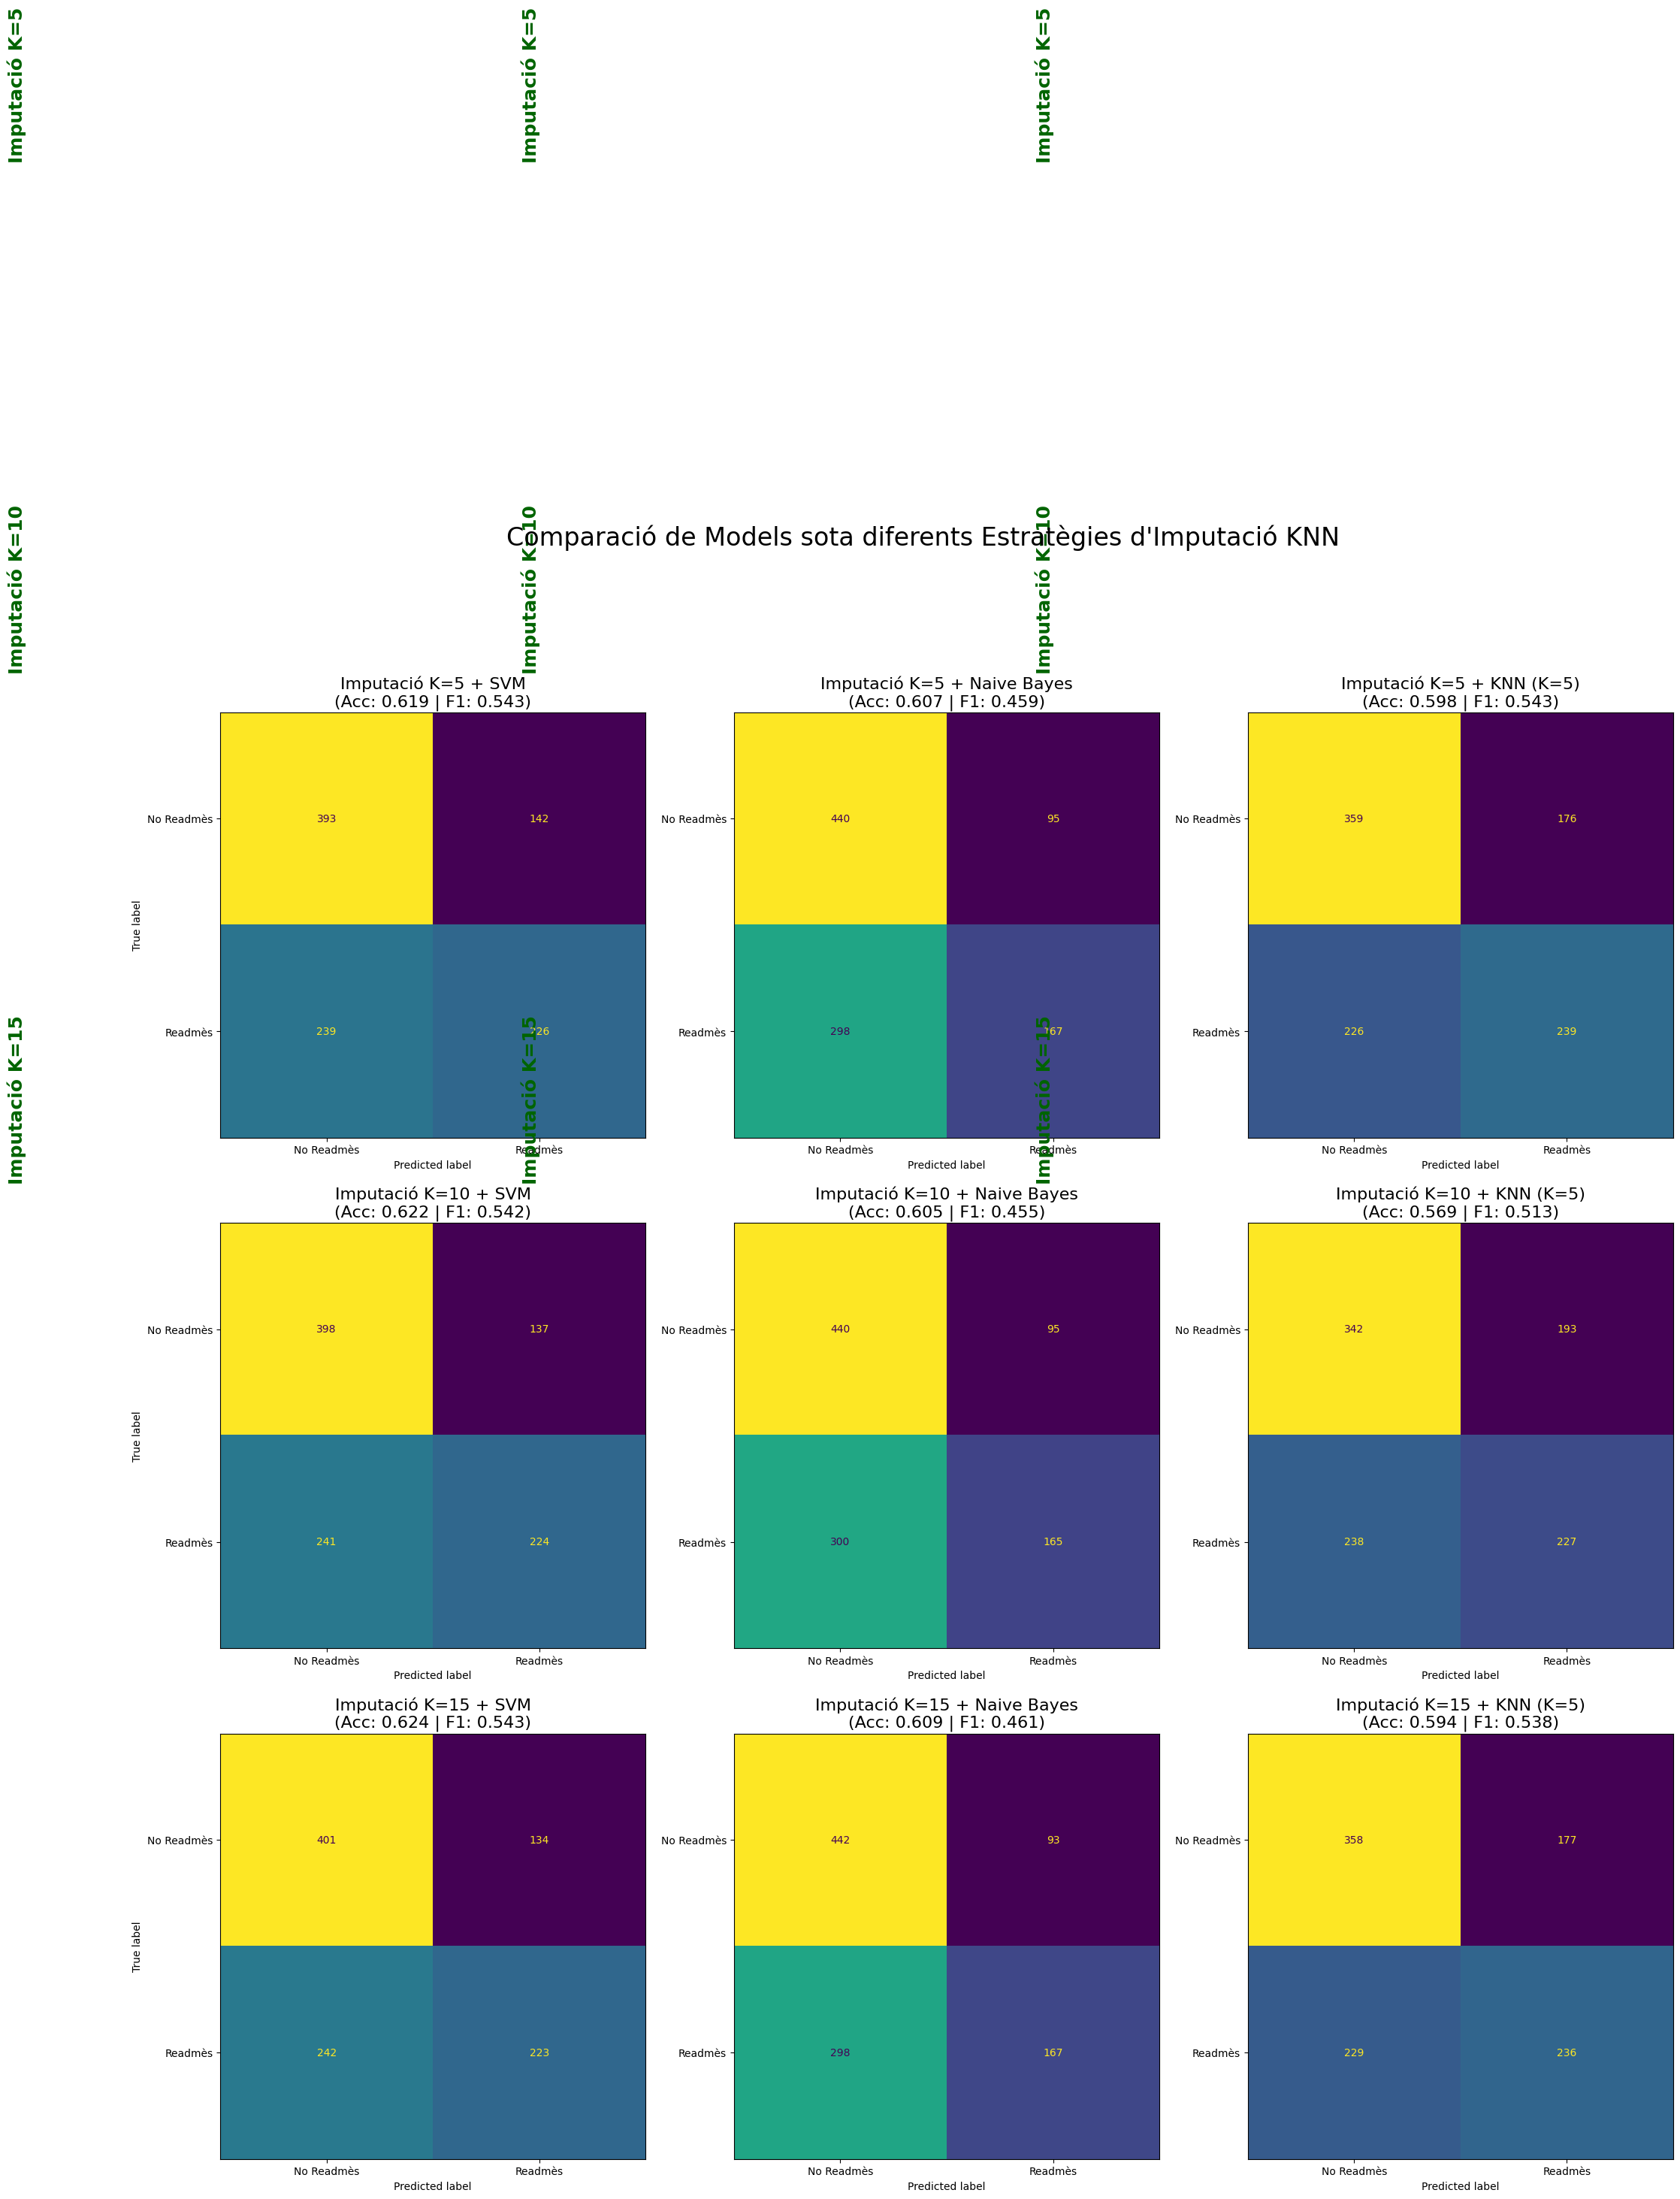


🏆 MILLOR RENDIMENT (Mesurat per F1-Score):
Model: Imputador K=5 + KNN (K=5) amb F1-Score: 0.5432


In [169]:
X_base, y_base = cargar_y_preparar(filename='diabetic_data.csv')
print(f"✅ Dades Base Sincronitzades. Mida inicial: {X_base.shape[0]} mostres.")

# --- DEFINICIÓN DE ESCENARIOS ---
# Los valores de K para el Imputer
K_imputer_values = [5, 10, 15]

# Los clasificadores a evaluar en cada escenario de imputación
models_to_evaluate = {
    'SVM': SVC(random_state=42),
    'Naive Bayes': GaussianNB(),
    'KNN (K=5)': KNeighborsClassifier(n_neighbors=5)
}

final_results = []
display_labels = ['No Readmès', 'Readmès']

# --- BUCLE PRINCIPAL: Imputación, Split, Escalado y Evaluación ---

for k_imputer in K_imputer_values:
    print(f"\n=======================================================")
    print(f"🟡 ESCENARIO DE IMPUTACIÓN: KNN (K={k_imputer})")
    print(f"=======================================================")
    
    X_input = X_base.copy()
    
    # 1. IMPUTACIÓN (con el K actual)
    imputer_knn = KNNImputer(n_neighbors=k_imputer)
    X_imputed_array = imputer_knn.fit_transform(X_input)
    X_final_imputed = pd.DataFrame(X_imputed_array, columns=X_base.columns)
    print(f"✅ Imputació per KNN (n_neighbors={k_imputer}) completada.")

    # 2. SPLIT Y ESCALADO
    X_train, X_test, y_train, y_test = train_test_split(
        X_final_imputed, y_base, test_size=0.2, random_state=42, stratify=y_base
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    print("✅ Split i Escalat completats.")

    # 3. EVALUACIÓN DE CLASIFICADORES
    for name, model in models_to_evaluate.items():
        full_name = f"Imputador K={k_imputer} + {name}"
        print(f"\n▶️ Avaluació del Model: {full_name}")
        
        # Entrenament
        model.fit(X_train_scaled, y_train)
        
        # Predicción
        y_pred = model.predict(X_test_scaled)
        
        # Métricas
        acc = accuracy_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)
        report = classification_report(y_test, y_pred, target_names=display_labels, output_dict=True, zero_division=0)
        f1_readmes = report['Readmès']['f1-score'] 

        print(f"   Accuracy: {acc:.4f} | F1-Score (Readmès): {f1_readmes:.4f}")

        # Guardar resultados para la visualización
        final_results.append({
            'name': full_name, 
            'cm': cm, 
            'acc': acc, 
            'f1': f1_readmes,
            'imputer_k': k_imputer
        })

# --- PASO 5: VISUALIZACIÓN DE LAS 9 MATRICES DE CONFUSIÓN ---

# Se utiliza un layout 3x3 para acomodar los 9 resultados
fig, axes = plt.subplots(3, 3, figsize=(25, 25)) 
axes = axes.flatten() 
plt.suptitle('Comparació de Models sota diferents Estratègies d\'Imputació KNN', fontsize=24)

# Para identificar el mejor resultado global
best_f1 = -1
best_model = ""

for i, res in enumerate(final_results):
    ax = axes[i]
    cm = res['cm']
    acc = res['acc']
    f1 = res['f1']
    imputer_k = res['imputer_k']
    model_name = res['name'].split(' + ')[-1]
    
    # Identificar el mejor modelo
    if f1 > best_f1:
        best_f1 = f1
        best_model = res['name']

    # Título más legible
    title = f"Imputació K={imputer_k} + {model_name}\n(Acc: {acc:.3f} | F1: {f1:.3f})"
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(ax=ax, cmap='viridis', values_format='d', colorbar=False) 
    disp.ax_.set_title(title, fontsize=16)
    
    # Ocultar etiquetas Y si no son el primer elemento de la fila
    if i % 3 != 0:
        disp.ax_.set_ylabel('')

    # Marcar la fila de cada Imputador
    if i < 3:
        disp.ax_.text(-0.5, 2.3, f"Imputació K={imputer_k}", transform=disp.ax_.transAxes, fontsize=18, fontweight='bold', color='darkgreen', rotation=90)
    elif i >= 3 and i < 6:
        disp.ax_.text(-0.5, 2.3, f"Imputació K={imputer_k}", transform=disp.ax_.transAxes, fontsize=18, fontweight='bold', color='darkgreen', rotation=90)
    elif i >= 6:
        disp.ax_.text(-0.5, 2.3, f"Imputació K={imputer_k}", transform=disp.ax_.transAxes, fontsize=18, fontweight='bold', color='darkgreen', rotation=90)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print(f"\n=======================================================")
print(f"🏆 MILLOR RENDIMENT (Mesurat per F1-Score):")
print(f"Model: {best_model} amb F1-Score: {best_f1:.4f}")
print(f"=======================================================")

✅ Dades Base Sincronitzades. Mida final: 5000 mostres.

🔴 ESTRATÈGIA ÚNICA: IMPUTACIÓ ITERATIVA (MICE)
✅ Imputació per MICE completada per a tots els models.
✅ Split i Escalat completats.

▶️ Avaluació del Model: 1. Regressió Logística
   Accuracy: 0.6050
   Matriu de Confusió:
[[399 136]
 [259 206]]

▶️ Avaluació del Model: 2. K-Nearest Neighbors (KNN)
   Accuracy: 0.6090
   Matriu de Confusió:
[[360 175]
 [216 249]]

▶️ Avaluació del Model: 3. Decision Tree Classifier
   Accuracy: 0.6200
   Matriu de Confusió:
[[451  84]
 [296 169]]


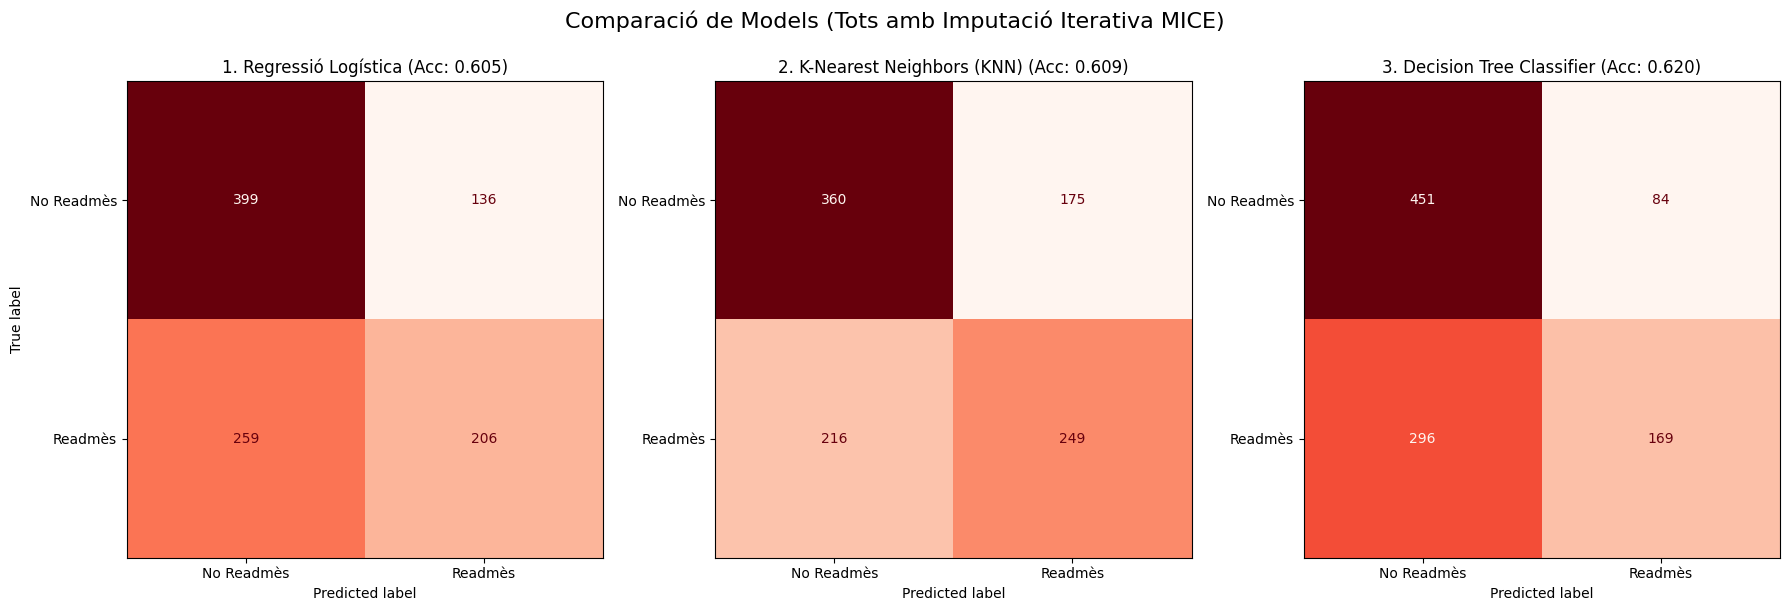

In [155]:
try:
    y_base_aligned = y_base.loc[X_base.index]
    y_base = y_base_aligned 
    print(f"✅ Dades Base Sincronitzades. Mida final: {X_base.shape[0]} mostres.")
except Exception as e:
    print(f"⚠️ ERROR DURANT L'ALINEACIÓ: {e}. Assegura't que X_base i y_base estan definides i són objectes pandas.")


# --- PAS 1: IMPUTACIÓ ITERATIVA (MICE) ---
print("\n" + "="*50)
print("🔴 ESTRATÈGIA ÚNICA: IMPUTACIÓ ITERATIVA (MICE)")

X_input = X_base.copy()
mice_imputer = IterativeImputer(
    max_iter=10, 
    random_state=42, 
    estimator=BayesianRidge()
) 
# NOTA: La imputació MICE pot ser lenta amb conjunts de dades grans.
X_mice_imputed_array = mice_imputer.fit_transform(X_input)
X_mice_imputed = pd.DataFrame(X_mice_imputed_array, columns=X_base.columns)

print("✅ Imputació per MICE completada per a tots els models.")

# --- PAS 2: PREPARACIÓ DE DADES (SPLIT I ESCALAT) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_mice_imputed, y_base, test_size=0.2, random_state=42, stratify=y_base
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("✅ Split i Escalat completats.")


# --- PAS 3: DEFINICIÓ DELS MODELS A AVALUAR ---
models_to_test = {
    '1. Regressió Logística': LogisticRegression(random_state=42, max_iter=1000),
    '2. K-Nearest Neighbors (KNN)': KNeighborsClassifier(n_neighbors=5),
    '3. Decision Tree Classifier': DecisionTreeClassifier(random_state=42, max_depth=5)
}

results = []
display_labels = ['No Readmès', 'Readmès']

# --- PAS 4: ENTRENAMENT I AVALUACIÓ DE CADA MODEL ---
for name, model in models_to_test.items():
    print(f"\n▶️ Avaluació del Model: {name}")
    
    # Entrenament
    model.fit(X_train_scaled, y_train)
    
    # Predicció
    y_pred = model.predict(X_test_scaled)
    
    # Mètriques
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"   Accuracy: {acc:.4f}")
    print("   Matriu de Confusió:")
    print(cm)
    
    # Guardar resultats per a la visualització
    results.append({'name': name, 'cm': cm, 'acc': acc})


# --- PAS 5: VISUALITZACIÓ DE LES TRES MATRIUS DE CONFUSIÓ ---

fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # Una fila, tres columnes
plt.suptitle('Comparació de Models (Tots amb Imputació Iterativa MICE)', fontsize=16)

for i, res in enumerate(results):
    ax = axes[i]
    cm = res['cm']
    acc = res['acc']
    title = f"{res['name']} (Acc: {acc:.3f})"
    
    # Utilitzem el teu mapa de color original 'Reds'
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(ax=ax, cmap='Reds', values_format='d', colorbar=False)
    disp.ax_.set_title(title)
    
    # Eliminem l'etiqueta Y a les matrius internes per netejar la visualització
    if i > 0:
        disp.ax_.set_ylabel('')
    
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [156]:
print("1. ESTRATÈGIA: ELIMINAR FILAS")

X_drop_selective = X_base.copy()
y_drop_selective = y_base.copy()
n_filas_antes_selectiu = len(X_drop_selective)

camps_nullable_per_imputacio = ['race', 'diag_2', 'diag_3'] 

camps_critics_per_drop = [col for col in X_drop_selective.columns if col not in camps_nullable_per_imputacio]

print("\n--- Camps CONSIDERATS NULEABLES (els seus nuls NO s'eliminaran) ---")
print(camps_nullable_per_imputacio)

X_drop_selective['target'] = y_drop_selective
X_drop_selective_clean = X_drop_selective.dropna(subset=camps_critics_per_drop)

y_drop_selective = X_drop_selective_clean['target']
X_drop_selective = X_drop_selective_clean.drop('target', axis=1)

n_filas_despues_selectiu = len(X_drop_selective)
pérdua_percentatge_selectiu = ((n_filas_antes_selectiu - n_filas_despues_selectiu) / n_filas_antes_selectiu) * 100
nuls_restants = X_drop_selective.isnull().sum().sum()

print("\n--- Valors després d'eliminar files ---")
print(f"Dimensió abans: {n_filas_antes_selectiu} files.")
print(f"Dimensió després: {n_filas_despues_selectiu} files.")
print(f"Files eliminades: {n_filas_antes_selectiu - n_filas_despues_selectiu} ({pérdua_percentatge_selectiu:.2f}%)")
print(f"Nuls totals restants (per imputar): {nuls_restants}")

print("\n--- Inspecció de Files i Nuls Restants ---")
if not X_drop_selective.empty:
    print("\nPrimeres 5 files netes (només nuls en camps anul·lables):")
    print(X_drop_selective.head())
    
    nuls_per_columna = X_drop_selective.isnull().sum()
    nuls_per_columna = nuls_per_columna[nuls_per_columna > 0]
    
    if not nuls_per_columna.empty:
        print("\nRecompte de Nuls per Columna (s'esperen nuls només en els camps Nul·lables):")
        print(nuls_per_columna)
    else:
        print("No queden nuls al DataFrame netejat.")
        
else:
    print("\n El DataFrame està buit (Dimensió: 0 files).")
    print("El resultat de l'eliminació és: pèrdua de gairebé el 100% de les dades.")

1. ESTRATÈGIA: ELIMINAR FILAS

--- Camps CONSIDERATS NULEABLES (els seus nuls NO s'eliminaran) ---
['race', 'diag_2', 'diag_3']

--- Valors després d'eliminar files ---
Dimensió abans: 5000 files.
Dimensió després: 16 files.
Files eliminades: 4984 (99.68%)
Nuls totals restants (per imputar): 3

--- Inspecció de Files i Nuls Restants ---

Primeres 5 files netes (només nuls en camps anul·lables):
      race  gender  age  admission_type_id  discharge_disposition_id  \
203    2.0     0.0  8.0                  6                         1   
864    2.0     1.0  7.0                  6                         6   
1201   3.0     0.0  5.0                  6                         1   
1239   2.0     0.0  7.0                  6                         1   
2101   2.0     1.0  7.0                  1                         1   

      admission_source_id  time_in_hospital  num_lab_procedures  \
203                     7                10                  81   
864                     1          

2. ESTRATÈGIA: ELIMINACIÓ DE FILES AMB NULS

Files originals: 5000
Files eliminades: 4986
Files restants per a l'anàlisi: 14

Eliminació de Files completada. Accuracy: 0.3333
Matriu de Confusió:
[[1 0]
 [2 0]]


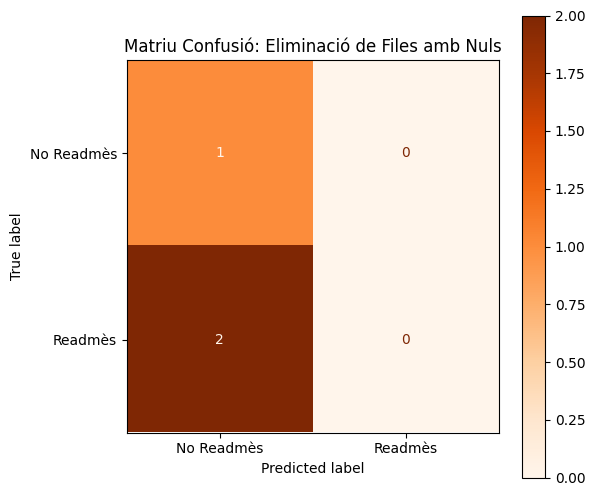

In [157]:
print("2. ESTRATÈGIA: ELIMINACIÓ DE FILES AMB NULS")

# Combinar X i y per eliminar nuls de manera coherent
df_combined = pd.concat([X_base, y_base], axis=1)

# Eliminació de files amb qualsevol valor nul
df_cleaned = df_combined.dropna()

X_deleted = df_cleaned.iloc[:, :-1]
y_deleted = df_cleaned.iloc[:, -1]

rows_deleted = len(X_base) - len(X_deleted)

print(f"\nFiles originals: {len(X_base)}")
print(f"Files eliminades: {rows_deleted}")
print(f"Files restants per a l'anàlisi: {len(X_deleted)}")

if len(X_deleted) == 0:
    print("ERROR: Totes les files contenen nuls. No es pot avaluar.")
else:
    # Avaluació
    X_train, X_test, y_train, y_test = train_test_split(
        X_deleted, y_deleted, test_size=0.2, random_state=42, stratify=y_deleted
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\nEliminació de Files completada. Accuracy: {acc:.4f}")
    print("Matriu de Confusió:")
    print(cm)

    # Generar Matriu de Confusió
    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Readmès', 'Readmès'])
    disp.plot(ax=ax, cmap='Oranges', values_format='d')
    disp.ax_.set_title('Matriu Confusió: Eliminació de Files amb Nuls')
    plt.show()

## 🛑 Análisis de la Estrategia: Eliminación Estricta de Nulos

El objetivo de cualquier tratamiento de datos es **preservar la máxima cantidad de información** para garantizar que el modelo de Machine Learning sea preciso y generalizable.

Su método de tratamiento de nulos (utilizando `dropna` en las columnas críticas) ha demostrado ser **inviable** para su conjunto de datos.

---

### 1. Pérdida Masiva e Inaceptable de Datos

La ejecución de su código mostró la siguiente destrucción del conjunto de datos:

| Métrica | Valor |
| :--- | :--- |
| **Dimensión Inicial** | 5000 filas |
| **Dimensión Final** | 16 filas |
| **Filas Eliminadas** | 4984 filas |
| **Pérdida Porcentual** | **99.68%** |

#### Consecuencia
Hemos **destruido el 99.68% de la información**. Un modelo entrenado con solo 16 muestras carece de **capacidad de generalización**. Su rendimiento será pobre y no tendrá ninguna validez estadística para predecir nuevos pacientes.

---

### 2. Alto Riesgo de Sesgo (Bias)

Al eliminar la vasta mayoría de las filas, se introduce un **sesgo de selección**.

* Las 16 filas restantes son solo aquellas que, por pura casualidad, tenían valores completos en todas sus variables "críticas".
* Es extremadamente improbable que estas 16 filas representen la **diversidad** o la **distribución** de las $5000$ muestras originales.
* Al entrenar el modelo solo con estos casos "perfectos", el modelo aprenderá solo de un subconjunto muy limitado de la población, fallando estrepitosamente con cualquier paciente "real" que contenga la variabilidad y los nulos esperados.

---

### 3. La Alternativa Viable

La inspección posterior a su `dropna` reveló que los **nulos restantes** en los campos anulables (`race`, `diag_2`, `diag_3`) eran mínimos (solo 3 en este caso particular).

La estrategia de tratamiento de nulos recomendada para este *dataset* es:

1.  **Mantener las 5000 filas originales (100% de los datos).**
2.  **Aplicar Imputación por Moda** a los valores nulos que haya en *todas* las columnas.

Esta alternativa preserva la validez de las $5000$ observaciones y es la única manera de construir un modelo predictivo robusto y usable.

2. ESTRATÈGIA: ELIMINACIÓ DE COLUMNES AMB NULS (Column Dropping)

Total de columnes originals: 44
Columnes eliminades (6): ['race', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult']
Columnes restants per a l'anàlisi: 38
No queden valors nuls al conjunt de dades.

Eliminació de Columnes completada. Accuracy: 0.6150
Matriu de Confusió:
[[406 129]
 [256 209]]


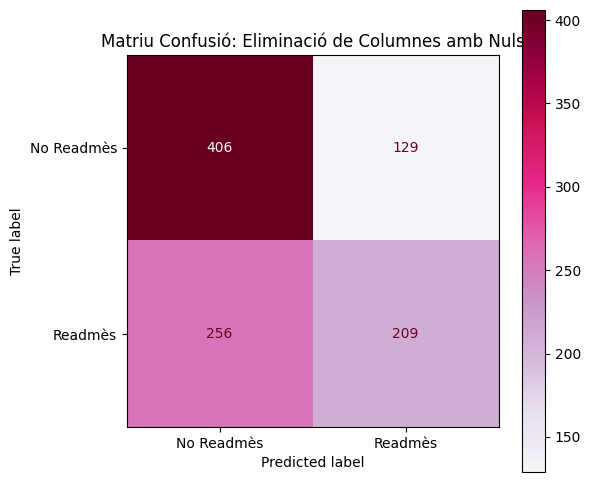

In [158]:
print("2. ESTRATÈGIA: ELIMINACIÓ DE COLUMNES AMB NULS (Column Dropping)")

# 1. Identificar les columnes amb Nuls
cols_with_nans = X_base.columns[X_base.isnull().any()]
num_cols_deleted = len(cols_with_nans)

# 2. Eliminar les columnes identificades
X_deleted_cols = X_base.drop(columns=cols_with_nans)

print(f"\nTotal de columnes originals: {len(X_base.columns)}")
print(f"Columnes eliminades ({num_cols_deleted}): {cols_with_nans.tolist()}")
print(f"Columnes restants per a l'anàlisi: {len(X_deleted_cols.columns)}")

# 3. Verificar que no queden nuls
if X_deleted_cols.isnull().sum().sum() == 0:
    print("No queden valors nuls al conjunt de dades.")
else:
    print("ERROR: Encara queden nuls. Revisar lògica.")
    
# 4. Avaluació amb Regressió Logística
X_train, X_test, y_train, y_test = train_test_split(
    X_deleted_cols, y_base, test_size=0.2, random_state=42, stratify=y_base
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"\nEliminació de Columnes completada. Accuracy: {acc:.4f}")
print("Matriu de Confusió:")
print(cm)

# 5. Generar Matriu de Confusió
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Readmès', 'Readmès'])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='PuRd', values_format='d')
disp.ax_.set_title('Matriu Confusió: Eliminació de Columnes amb Nuls')
plt.show()

🚀 FASE 1: Preparación Final de Datos para el Modelado (OHE y Escalado)

In [ ]:
# ----------------------------------------------------------------------
# IMPORTANTE: DEBES CARGAR O DEFINIR ESTAS VARIABLES EN TU CUADERNO
# X_deleted_cols: Tu DataFrame de features limpio.
# y_base: Tu variable objetivo binaria (0 o 1).
# ----------------------------------------------------------------------

# 1. Codificación Categórica (One-Hot Encoding - OHE)
# Identifica columnas categóricas (tipo 'object')
categorical_cols = X_deleted_cols.select_dtypes(include=['object']).columns.tolist()

# Aplicar OHE. drop_first=True evita la multicolinealidad
X_final = pd.get_dummies(X_deleted_cols, columns=categorical_cols, drop_first=True)

# 2. División y Escalado
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_base, test_size=0.2, random_state=42, stratify=y_base
)

# Aplicar Escalado (NECESARIO para KNN, SVM, MLP)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("--- FASE 1: PREPARACIÓN COMPLETA ---")
print(f"Dataset Final con {X_train.shape[1]} features listo para modelar.")

--- FASE 1: PREPARACIÓN COMPLETA ---
Dataset Final con 38 features listo para modelar.


2. FASE 2: Benchmark de Modelos Clave (KNN, SVM, RF)

In [160]:
results = {}
print("\n--- FASE 2: BENCHMARK DE MODELOS ---")

# --- A. Modelos Basados en Distancia (Usan datos ESCALADOS) ---

# 1. K-Nearest Neighbors (KNN)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
results['KNN'] = classification_report(y_test, y_pred_knn, output_dict=True)

# 2. Support Vector Machine (SVM)
svc = SVC(kernel='rbf', random_state=42)
svc.fit(X_train_scaled, y_train)
y_pred_svc = svc.predict(X_test_scaled)
results['SVM'] = classification_report(y_test, y_pred_svc, output_dict=True)

# --- B. Modelo de Ensamble (Usa datos SIN ESCALAR) ---

# 3. Random Forest (RF)
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10) 
rf.fit(X_train, y_train) 
y_pred_rf = rf.predict(X_test)
results['RandomForest'] = classification_report(y_test, y_pred_rf, output_dict=True)

print("\n--- Rendimiento Comparativo (F1-Score Readmisión) ---")
for model_name, report in results.items():
    print(f"Modelo {model_name}: F1-Score (Clase 1) = {report['1']['f1-score']:.4f}")


--- FASE 2: BENCHMARK DE MODELOS ---

--- Rendimiento Comparativo (F1-Score Readmisión) ---
Modelo KNN: F1-Score (Clase 1) = 0.5599
Modelo SVM: F1-Score (Clase 1) = 0.5483
Modelo RandomForest: F1-Score (Clase 1) = 0.5617


3. FASE 3: Red Neuronal y Optimización de Random Forest


--- FASE 3: OPTIMIZACIÓN DEL MODELO ---
Fitting 3 folds for each of 8 candidates, totalling 24 fits

--- Resultados de Optimización (Random Forest) ---
Mejores Hiperparámetros: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Reporte del Mejor Modelo RF:
              precision    recall  f1-score   support

           0       0.63      0.72      0.67       535
           1       0.61      0.51      0.56       465

    accuracy                           0.62      1000
   macro avg       0.62      0.61      0.61      1000
weighted avg       0.62      0.62      0.62      1000



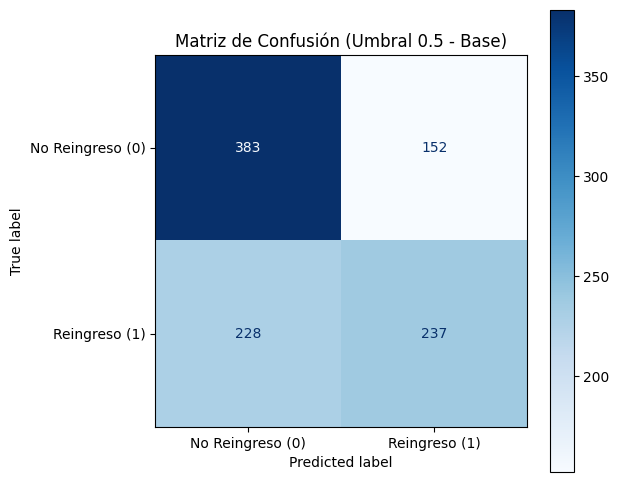

In [161]:
# --- A. Optimización del Mejor Modelo (Random Forest) ---
print("\n--- FASE 3: OPTIMIZACIÓN DEL MODELO ---")

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10], 
    'min_samples_split': [5, 10]
}

# Optimizamos utilizando la métrica 'f1'
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1', 
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train) # Usa datos SIN escalar

best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

print("\n--- Resultados de Optimización (Random Forest) ---")
print(f"Mejores Hiperparámetros: {grid_search.best_params_}")
print("Reporte del Mejor Modelo RF:")
print(classification_report(y_test, y_pred_best_rf))

# --- B. Visualización de la Matriz de Confusión Base (Umbral 0.5) ---
cm_default = confusion_matrix(y_test, y_pred_best_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_default, display_labels=['No Reingreso (0)', 'Reingreso (1)'])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Matriz de Confusión (Umbral 0.5 - Base)')
plt.show()

FASE 4: Análisis de Negocio (Importancia y Umbral)


--- FASE 4: UTILIDAD Y VISUALIZACIÓN ---


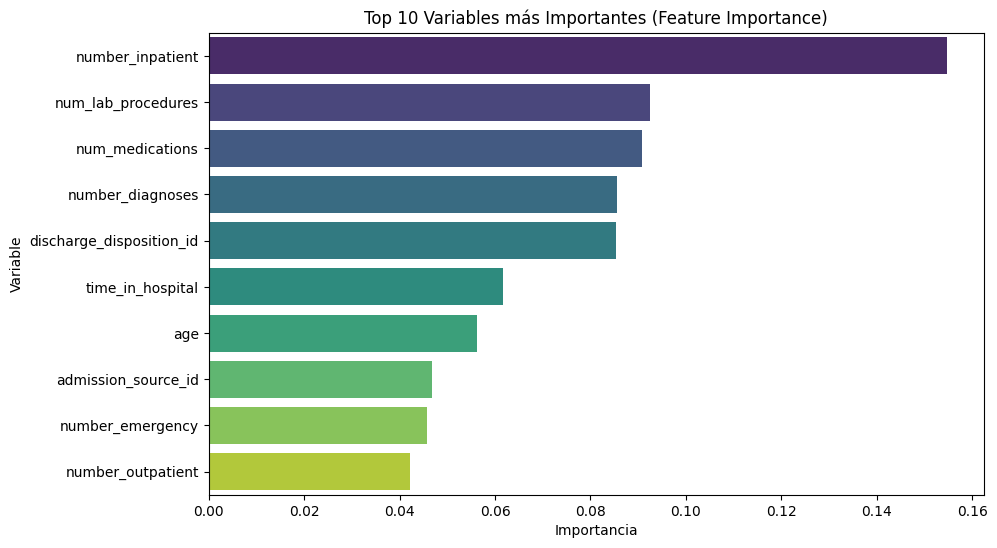


--- Análisis del Umbral Ajustado (Umbral = 0.3) ---
Recall (Sensibilidad) Anterior (Umbral 0.5): 0.5097
Recall Nuevo (Umbral 0.3): 0.9376

Falsos Negativos (Umbral 0.5): 228
Falsos Negativos (Umbral 0.3): 29 (¡Reducción lograda!)


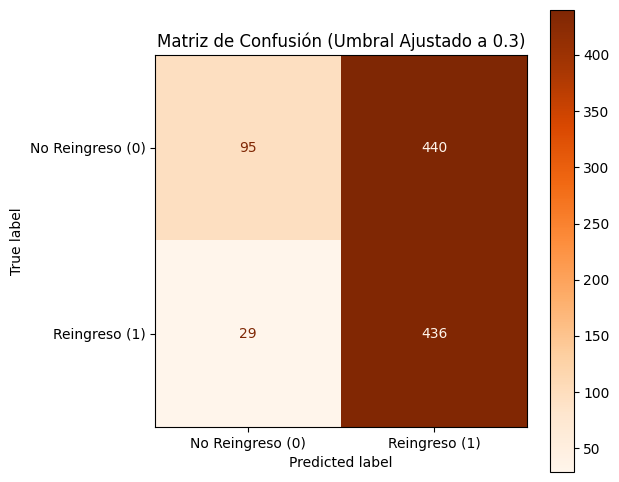


--- UTILIDAD FINAL: PREDICCIÓN DE NUEVO PACIENTE ---
Probabilidad de Reingreso: 0.5320
Predicción Final (Umbral 0.3): Reingreso


In [ ]:
# --- A. Visualización de la Importancia de Variables ---
print("\n--- FASE 4: UTILIDAD Y VISUALIZACIÓN ---")

feature_importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
top_10_features = feature_importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_features.values, y=top_10_features.index, palette="viridis")
plt.title('Top 10 Variables más Importantes (Feature Importance)')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.show()


# --- B. Ajuste del Umbral de Decisión y Visualización ---

# 1. Obtener probabilidades
y_proba = best_rf.predict_proba(X_test)[:, 1] 

# 2. Umbral de Decisión ajustado (priorizar Recall)
new_threshold = 0.3 

# 3. Generar predicciones con el nuevo umbral
y_pred_threshold = np.where(y_proba >= new_threshold, 1, 0)

# 4. Evaluación del impacto
new_recall = recall_score(y_test, y_pred_threshold)
new_cm = confusion_matrix(y_test, y_pred_threshold)

print(f"\n--- Análisis del Umbral Ajustado (Umbral = {new_threshold}) ---")
print(f"Recall (Sensibilidad) Anterior (Umbral 0.5): {cm_default[1, 1] / (cm_default[1, 0] + cm_default[1, 1]):.4f}")
print(f"Recall Nuevo (Umbral {new_threshold}): {new_recall:.4f}")
print(f"\nFalsos Negativos (Umbral 0.5): {cm_default[1, 0]}") 
print(f"Falsos Negativos (Umbral {new_threshold}): {new_cm[1, 0]} (¡Reducción lograda!)")

# Visualización de la Matriz de Confusión Ajustada
disp_adj = ConfusionMatrixDisplay(confusion_matrix=new_cm, display_labels=['No Reingreso (0)', 'Reingreso (1)'])
fig, ax = plt.subplots(figsize=(6, 6))
disp_adj.plot(ax=ax, cmap='Oranges', values_format='d')
plt.title(f'Matriz de Confusión (Umbral Ajustado a {new_threshold})')
plt.show()


# --- C. Demostración de Utilidad: Predicción con Nuevo Paciente (CÓDIGO CORREGIDO) ---

print("\n--- UTILIDAD FINAL: PREDICCIÓN DE NUEVO PACIENTE ---")

# 1. CREACIÓN DEL TEMPLATE: Creamos un DataFrame con ceros que tiene TODAS las columnas
paciente_ejemplo = pd.DataFrame(0, index=[0], columns=X_train.columns)

# 2. DEFINICIÓN DEL PACIENTE DE ALTO RIESGO
paciente_ejemplo['num_lab_procedures'] = 80   
paciente_ejemplo['num_medications'] = 50      
paciente_ejemplo['time_in_hospital'] = 14     
paciente_ejemplo['number_diagnoses'] = 9      

# Activamos una columna OHE. Asume que tu columna de edad 60-70 se llama 'age_60-70'
if 'age_60-70' in paciente_ejemplo.columns:
    paciente_ejemplo['age_60-70'] = 1
# Si tienes una columna OHE de 'insulin', la puedes activar aquí:
if 'insulin_Steady' in paciente_ejemplo.columns:
    paciente_ejemplo['insulin_Steady'] = 1

# 3. Predicción de Probabilidad
probabilidad_readmision = best_rf.predict_proba(paciente_ejemplo)[0, 1]

# 4. Predicción Final con el umbral ajustado
prediccion_final = "Reingreso" if probabilidad_readmision >= new_threshold else "No Reingreso"

print(f"Probabilidad de Reingreso: {probabilidad_readmision:.4f}")
print(f"Predicción Final (Umbral {new_threshold}): {prediccion_final}")

COMO HACEMOS EL TRATAMIENTO POR COLUMNAS?